In [1]:
from run_any_data import *

## Loading the data files

#### NOTE: to use the fitting function you need to provide the uncertainty for both x- and y-data (e.g. energy and flux).  For the uncertainty you can use for example 10% of the x and y data.
<br> provide the path to the file. The file can be in either txt or csv format. If the data is in xlsx format use pd.read_excel() instead of pd.read_csv()


In [2]:
#path_to_file = r'C:/Users/Omistaja/Desktop/SRL/2021SRL/messenger/event1.txt'
path =  r'/home/annafed/Documents/EPD-energy-geom/test_file.csv'
data = pd.read_csv(path) # or pd.read_excel() for xlsx data


In [3]:
data

,x,x_err_up,x_err_low,x_all,x_err_up_all,x_err_low_all,y,y_err,y_all,y_err_all
0,0.004571,0.000252,0.000230,0.004571,0.000279,0.000232,1.311626e+07,843557.425959,1.055976e+07,220831.423233
1,0.004955,0.000248,0.000265,0.004955,0.000259,0.000253,1.023653e+07,729627.159474,9.109099e+06,192614.623213
2,0.005309,0.000293,0.000243,0.005370,0.000269,0.000310,9.019675e+06,644018.256159,7.949702e+06,166378.759065
3,0.005754,0.000293,0.000257,0.005754,0.000331,0.000263,7.595381e+06,544869.904777,7.056044e+06,144668.864811
4,0.006237,0.000308,0.000268,0.006237,0.000351,0.000277,6.646785e+06,493442.972571,6.241724e+06,131153.203795
...,...,...,...,...,...,...,...,...,...,...
65,0.512000,0.039471,0.040030,0.512000,0.039471,0.040030,3.256238e+03,319.447332,3.256238e+03,319.447332
66,0.622207,0.106045,0.090923,0.622207,0.106045,0.090923,1.187454e+03,14.307159,1.187454e+03,14.307159
67,1.128840,0.336572,0.253392,1.128840,0.336572,0.253392,4.082418e+01,1.047563,4.082418e+01,1.047563
68,3.407210,0.467400,0.437544,3.407210,0.467400,0.437544,1.224869e+01,0.377948,1.224869e+01,0.377948


#### Choose what to fit. The file can contain all kinds of data and multiple columns etc. Below, you need to choose what you want to fit. Choose x-axis data and y-axis data. 

In [4]:
x_data = data['x']
y_data = data['y']
#x_err = data['name of column with x uncertainty data'] 
#y_err = data['name of column with y uncertainty data']

# if the data doesn't contain uncertainty it still needs to be provided for the fitting functions to works
# e.g. use 10% of the data 
x_err = data['x_err_up']
y_err = data['y_err']


## Saving data 
#### You can choose to save the plot (savefig), the ODR run as a pickle file (save_pickle) and save all the variables from the fitting procedure (save_fit_variables) by setting the options below to True

In [5]:
savefig = False # save the fit
save_pickle = False # save a pickle file of the odr run
save_fit_variables = False # save the variables from the fit

In [6]:
data_for_the_fit = pd.DataFrame()
data_for_the_fit['x'] = x_data
data_for_the_fit['y'] = y_data
data_for_the_fit['x error'] = x_err
data_for_the_fit['y error'] = y_err

data_for_the_fit_list = [data_for_the_fit]

In [7]:
data_for_the_fit

,x,y,x error,y error
0,0.004571,1.311626e+07,0.000252,843557.425959
1,0.004955,1.023653e+07,0.000248,729627.159474
2,0.005309,9.019675e+06,0.000293,644018.256159
3,0.005754,7.595381e+06,0.000293,544869.904777
4,0.006237,6.646785e+06,0.000308,493442.972571
...,...,...,...,...
65,0.512000,3.256238e+03,0.039471,319.447332
66,0.622207,1.187454e+03,0.106045,14.307159
67,1.128840,4.082418e+01,0.336572,1.047563
68,3.407210,1.224869e+01,0.467400,0.377948


In [8]:
plot_title = 'Test Bow_tie'
x_label = 'Energy (MeV)'
y_label = 'Flux\n/(s cm² sr MeV)'
legend_title = '' 

## INPUTS FOR THE FIT

### which_fit options: 
<br>'single' will force a single pl fit to the data
<br> 'broken' will force a broken pl fit to the data but ONLY if the break point is within the energy range otherwise a sigle pl fit will be produced instead
<br> 'best_sb' will choose automatically the best fit type between single and broken by comparing the redchis of the fits
<br> 'cut' will produce a single pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken or single pl will be fit instead
<br> 'broken_cut' will produce a broken pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken or single pl will be fit instead
<br> 'best_cb' will choose the better option between a broken pl and a single+cutoff. If the break and cutoff points are outside of the energy range a single pl will be fit instead.
<br>'triple' will try to fit a triple pl. If not possible, will try to fit the next best option.
<br> 'best' will choose automatically the best fit type by comparing the redchis of the fits


In [9]:
which_fit = 'best' 

## Guess values and energy range
#### NOTE: e_min, e_max, break_guess and cut_guess should bein MeV. e_min and e_max can also be None. In this case the MAKE_THE_FIT function will automaically choose the values. (energy on x-axis)

<br>Random and iterations
<br>if use_random = False the fit will only be made once with the guess values
<br> if use_random = True the fitting function will first create a list of reasonable values for each of the fitting parameters then randomly select values from the lists and compare the redchis of each fit to find the best one
<br> iterations = number of times the fit is retried to find the best one

In [10]:
e_min =  None # in MeV 
e_max = None# in MeV

g1_guess = -1.9 # gamma 1 -> spectral index before the break (or single pl)
g2_guess = -2.5 # gamma 2 -> spectral index after the break (for broken pl)
g3_guess = -4.5 # gamma 3 -> spectral index after the second break (for triple pl)
c1_guess = 1e3 # peak flux
alpha_guess = 7.16 # sharpness of the first break
beta_guess = 10 #sharpness of the second break
break_guess_low = 0.06 #in MeV
break_guess_high = 0.12
cut_guess = 0.12 #in MeV

#legend_details = False

use_random = True 
iterations = 20

which_fit = 'best' 

In [17]:
plot_title = 'Test Bow-Tie'
x_label = 'Energy (MeV)'
y_label = 'Intensity\n/(s cm² sr MeV)'
legend_title = '' 

           x             y   x error        y error
0   0.004571  1.311626e+07  0.000252  843557.425959
1   0.004955  1.023653e+07  0.000248  729627.159474
2   0.005309  9.019675e+06  0.000293  644018.256159
3   0.005754  7.595381e+06  0.000293  544869.904777
4   0.006237  6.646785e+06  0.000308  493442.972571
..       ...           ...       ...            ...
65  0.512000  3.256238e+03  0.039471     319.447332
66  0.622207  1.187454e+03  0.106045      14.307159
67  1.128840  4.082418e+01  0.336572       1.047563
68  3.407210  1.224869e+01  0.467400       0.377948
69  9.533234  9.158257e-01  1.516948       0.054862

[70 rows x 4 columns]


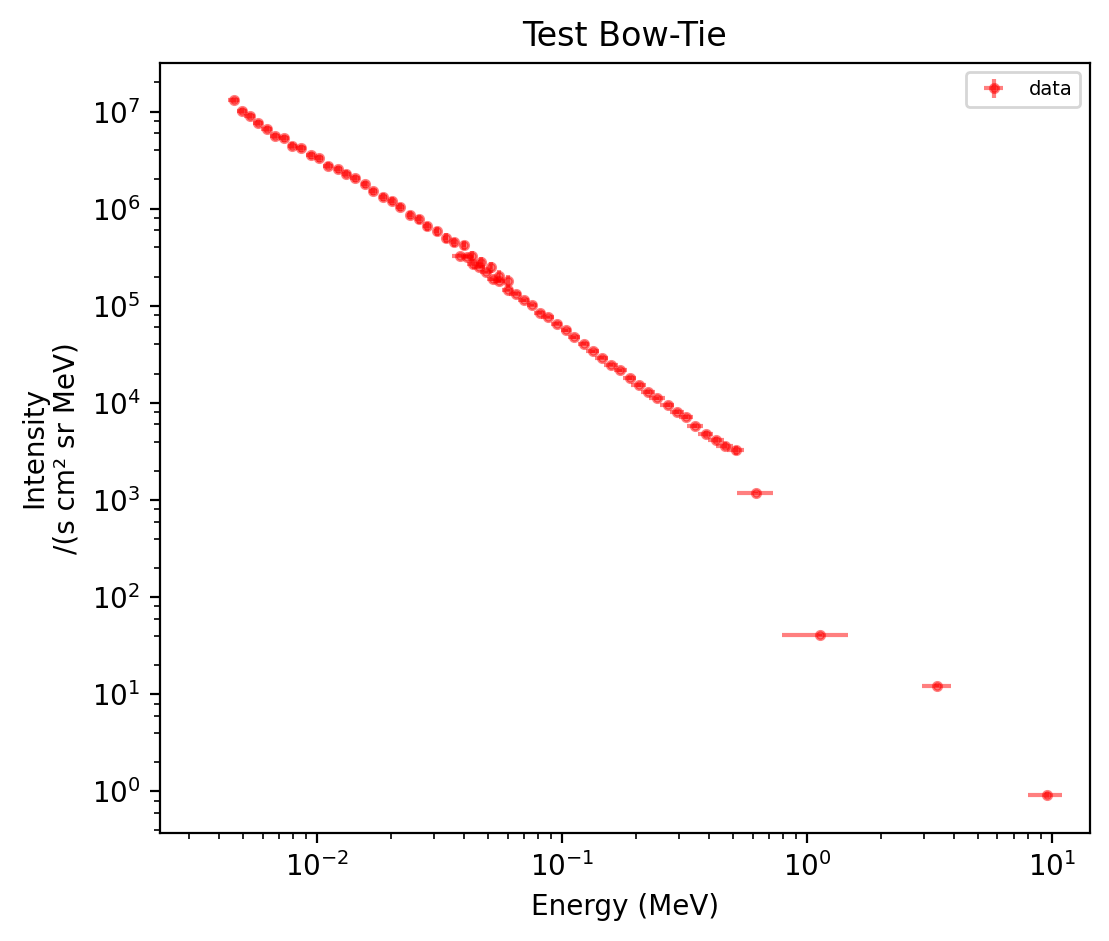

In [18]:
run_all(path, data_for_the_fit_list, savefig = True, plot_title = plot_title, x_label = x_label, y_label = y_label, legend_title = legend_title, which_fit = 'single',  e_min = e_min, e_max = e_max, g1_guess =g1_guess, g2_guess = g2_guess, g3_guess = g3_guess, c1_guess = c1_guess, alpha_guess = alpha_guess, beta_guess = beta_guess, break_guess_low = break_guess_low, break_guess_high = break_guess_high, cut_guess = cut_guess, use_random = use_random, iterations = iterations , legend_details = True)
            # data, savefig, plot_title = '', x_label = 'Intensity [/]', y_label = 'Energy [MeV]', legend_title = '', data_label_for_legend = ['data'], which_fit = 'best', e_min = None, e_max = None, g1_guess = -1.9, g2_guess = -2.5, g3_guess = -4, c1_guess = 1000, alpha_guess = 10, beta_guess = 10, break_guess_low = 0.6, break_guess_high = 1.2, cut_guess = 1.2, use_random = True, iterations = 20 , legend_details = False):
    